# Прогноз удовлетворённости клиента для маркетплейса Olist
## Часть 3. Машинное обучение

**Автор:** Adilkhan Iskindirov

---

### Что делаем

Обучаем и честно сравниваем модели, предсказывающие негативную оценку (1–2 звезды)
по данным, известным **в момент доставки заказа**.

### Что уже известно из EDA (часть 2)

| Находка | Следствие для моделирования |
|---|---|
| Негатив = 12.8% выборки | Accuracy бесполезна; основная метрика — PR-AUC |
| Срыв обещанного срока: 9–12% → 32–79% негатива | Главный признак; порог резкий, а не плавный |
| Но опоздавших всего 6.7% заказов | Объективный потолок качества — сильный сигнал покрывает малую часть |
| Долгая, но обещанная доставка переносится спокойно | Важен `late_days`, а не `delivery_days` сам по себе |
| Категория, состав заказа, регион — слабые факторы | Полезны, но погоды не сделают |
| `late_days` в SQL считался дробно и был зашумлён | Исправлено в `feat_sql.py` v2, добавлен `is_late` |

### Что важно понимать заранее

Это **не задача с высоким потолком**. Причины негатива, не связанные с логистикой
(товар не подошёл, качество хуже ожиданий), в датасете физически отсутствуют.
Поэтому цель — не выжать максимальную метрику, а честно измерить, где модель
работает, и перевести это в понятную бизнесу пользу.

## 1. Подготовка

In [1]:
import os
import sqlite3
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_predict
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, precision_score,
    recall_score, confusion_matrix, precision_recall_curve, roc_curve,
    classification_report,
)

warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
OK, BAD, NEUTRAL = "#1C7293", "#C0392B", "#8395A7"

SEED = 42
DB_PATH = "olist.db"
FEATURES_CSV = "features_v2.csv"

In [2]:
# Признаки собраны SQL-запросом из feat_sql.py (v2 — с исправленным late_days).
if os.path.exists(FEATURES_CSV):
    df = pd.read_csv(FEATURES_CSV, parse_dates=["order_purchase_timestamp"])
else:
    from feat_sql import FEATURE_SQL
    with sqlite3.connect(DB_PATH) as conn:
        df = pd.read_sql(FEATURE_SQL, conn, parse_dates=["order_purchase_timestamp"])
    df.to_csv(FEATURES_CSV, index=False)

# Целевая переменная: 1 = клиент недоволен (1-2 звезды). Обоснование порога — в части 2.
df["low_review"] = (df.review_score <= 2).astype(int)

print(f"Заказов: {len(df):,} | признаков: {df.shape[1] - 3}")
print(f"Период: {df.order_purchase_timestamp.min():%Y-%m-%d} — {df.order_purchase_timestamp.max():%Y-%m-%d}")
print(f"Доля негатива: {df.low_review.mean():.2%}")
print(f"Доля опоздавших заказов: {df.is_late.mean():.2%}")

Заказов: 95,823 | признаков: 25
Период: 2016-10-03 — 2018-08-29
Доля негатива: 12.85%
Доля опоздавших заказов: 6.66%


## 2. Разделение выборки

Разбиение стратифицированное — доля негатива одинакова в обеих частях.
Отдельно, в разделе 8, проверим модель на разбиении **по времени**: это ближе
к реальному сценарию, когда модель обучают на прошлом и применяют к будущему.

In [3]:
DROP = ["order_id", "order_purchase_timestamp", "review_score", "low_review"]
X = df.drop(columns=DROP)
y = df.low_review

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Доля негатива — train: {y_train.mean():.3f} | test: {y_test.mean():.3f}")

Train: 76,658 | Test: 19,165
Доля негатива — train: 0.128 | test: 0.128


In [4]:
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

print(f"Числовых признаков: {len(num_cols)}")
print(f"Категориальных: {len(cat_cols)} -> {cat_cols}")
for col in cat_cols:
    print(f"  {col}: {X[col].nunique()} уникальных значений")

Числовых признаков: 20
Категориальных: 4 -> ['payment_type', 'product_category', 'customer_state', 'seller_state']
  payment_type: 4 уникальных значений
  product_category: 72 уникальных значений
  customer_state: 27 уникальных значений
  seller_state: 22 уникальных значений


In [5]:
# Препроцессинг:
#  - числовые: медианная импутация (пропусков <1.5%, см. часть 2) + масштабирование
#    (нужно логистической регрессии; деревьям безвредно)
#  - категориальные: one-hot. min_frequency=100 схлопывает редкие категории и штаты
#    в одну группу 'infrequent' — иначе получим десятки почти пустых столбцов,
#    на которых модель будет переобучаться
preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), num_cols),
    ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist",
                          min_frequency=100, sparse_output=False), cat_cols),
])

n_features_out = preprocess.fit(X_train).transform(X_train.head(5)).shape[1]
print(f"Признаков после препроцессинга: {n_features_out}")

Признаков после препроцессинга: 114


## 3. Выбор метрики

При доле позитивного класса 12.8% **accuracy непригодна**: модель, всегда
отвечающая «клиент доволен», получит 87% точности и нулевую пользу.

Что используем и почему:

- **PR-AUC (average precision) — главная метрика.** Показывает качество
  на редком классе во всём диапазоне порогов. В отличие от ROC-AUC не
  «разбавляется» огромным числом лёгких отрицательных примеров. Базовый
  уровень для случайной модели равен доле позитивного класса, то есть **0.128** —
  с этим числом и сравниваем.
- **ROC-AUC** — вторичная, для сопоставимости с внешними бенчмарками.
- **Precision / Recall / F1 при подобранном пороге** — то, что реально видит
  бизнес: сколько тревог ложные и сколько проблемных заказов упущено.

Порог 0.5 по умолчанию для несбалансированной задачи бессмыслен — его
подбираем отдельно в разделе 6.

In [6]:
BASE_RATE = y_train.mean()
print(f"Базовый уровень PR-AUC (случайная модель): {BASE_RATE:.4f}")

Базовый уровень PR-AUC (случайная модель): 0.1285


## 4. Базовое сравнение моделей

Три модели разной природы:

- **Logistic Regression** — линейная база. Нужна как точка отсчёта: если сложные
  модели её не обходят, значит в данных нет нелинейной структуры.
- **Random Forest** — ансамбль независимых деревьев, усреднение голосов.
- **HistGradientBoosting** — бустинг: деревья строятся последовательно, каждое
  исправляет ошибки предыдущих. Обычно сильнее леса на табличных данных.

У линейной модели и леса стоит `class_weight="balanced"` — штраф за ошибку
на редком классе пропорционально выше. У бустинга такого параметра нет,
вместо него работает подбор порога (раздел 6).

In [7]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te, fit=True):
    """Обучает модель и считает метрики на тестовой выборке при пороге 0.5."""
    import time
    t0 = time.time()
    if fit:
        model.fit(X_tr, y_tr)
    fit_sec = time.time() - t0

    proba = model.predict_proba(X_te)[:, 1]
    pred = (proba >= 0.5).astype(int)

    return {
        "ROC-AUC":   roc_auc_score(y_te, proba),
        "PR-AUC":    average_precision_score(y_te, proba),
        "F1@0.5":    f1_score(y_te, pred),
        "Precision@0.5": precision_score(y_te, pred, zero_division=0),
        "Recall@0.5":    recall_score(y_te, pred),
        "fit, сек":  round(fit_sec, 1),
    }, proba

In [8]:
models = {
    "Logistic Regression": Pipeline([
        ("prep", preprocess),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=SEED)),
    ]),
    "Random Forest": Pipeline([
        ("prep", preprocess),
        ("clf", RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                       class_weight="balanced", n_jobs=-1, random_state=SEED)),
    ]),
    "HistGradientBoosting": Pipeline([
        ("prep", preprocess),
        ("clf", HistGradientBoostingClassifier(random_state=SEED)),
    ]),
}

results, probas = {}, {}
for name, model in models.items():
    results[name], probas[name] = evaluate(name, model, X_train, y_train, X_test, y_test)
    print(f"{name} — готово")

baseline_tbl = pd.DataFrame(results).T
baseline_tbl.round(4)

Logistic Regression — готово


Random Forest — готово


HistGradientBoosting — готово


,ROC-AUC,PR-AUC,F1@0.5,Precision@0.5,Recall@0.5,"fit, сек"
Logistic Regression,0.7597,0.4387,0.4403,0.3812,0.5211,0.9
Random Forest,0.7643,0.4712,0.4626,0.5373,0.4062,39.8
HistGradientBoosting,0.7626,0.4810,0.4139,0.7489,0.2859,2.3


**Вывод.** Обе ансамблевые модели уверенно обходят линейную по PR-AUC, то есть
нелинейная структура в данных действительно есть — это ожидаемо, учитывая
пороговый характер главного признака (опоздал / не опоздал).

Обратите внимание на колонки при пороге 0.5: у логистической регрессии
высокий recall и низкая precision (она с `class_weight="balanced"` склонна
объявлять негативом всё подозрительное), у бустинга наоборот — высокая
precision и низкий recall. Это ровно та причина, по которой **сравнивать
модели по F1 при пороге 0.5 нельзя**: цифры отражают не качество модели,
а случайное положение дефолтного порога относительно распределения
вероятностей. Сравнение честно только по PR-AUC и ROC-AUC, которые от порога
не зависят.

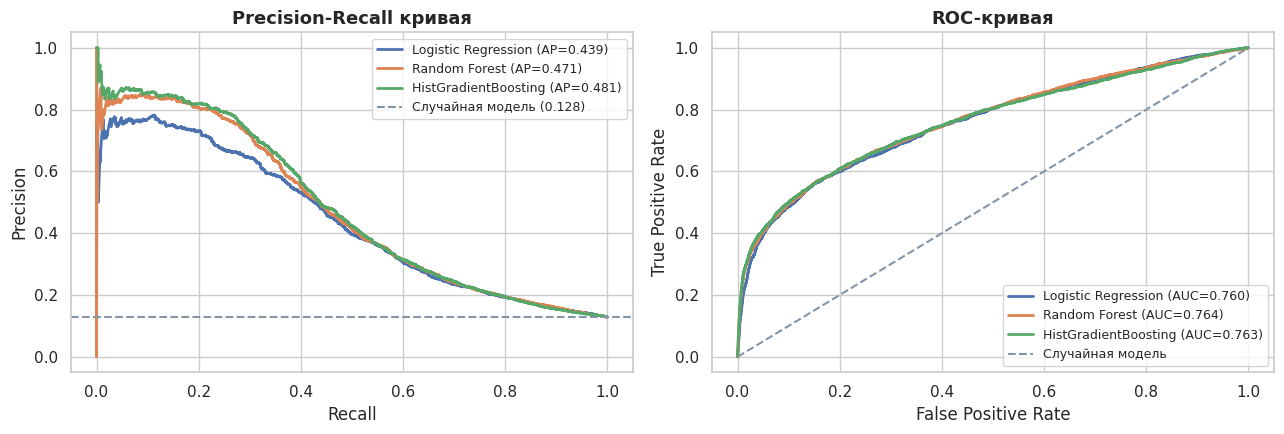

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for name, proba in probas.items():
    p, r, _ = precision_recall_curve(y_test, proba)
    axes[0].plot(r, p, lw=2, label=f"{name} (AP={average_precision_score(y_test, proba):.3f})")
axes[0].axhline(y_test.mean(), color=NEUTRAL, ls="--", lw=1.5,
                label=f"Случайная модель ({y_test.mean():.3f})")
axes[0].set_title("Precision-Recall кривая")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision"); axes[0].legend(fontsize=9)

for name, proba in probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[1].plot(fpr, tpr, lw=2, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
axes[1].plot([0, 1], [0, 1], color=NEUTRAL, ls="--", lw=1.5, label="Случайная модель")
axes[1].set_title("ROC-кривая")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()

**Вывод.** PR-кривая (слева) показывает главное ограничение задачи наглядно:
при высоком recall precision быстро падает к базовому уровню. То есть поймать
**всех** недовольных модель не может — за пределами логистических причин
негатив для неё неотличим от фона, ровно как и предсказывал EDA.

Зато в левой части кривой, при низком recall, precision держится высоко:
среди заказов, которые модель считает самыми рискованными, доля реально
недовольных в разы выше средней. Это и есть рабочая зона — на ней и будем
строить бизнес-применение.

## 5. Подбор гиперпараметров

Тюним лучшую по PR-AUC модель. Используем `RandomizedSearchCV`: при сопоставимом
качестве он дешевле полного перебора, а при 5 параметрах полная сетка потребовала
бы сотни обучений.

`scoring="average_precision"` — оптимизируем именно PR-AUC, а не accuracy.
`cv=3` со стратификацией — компромисс между надёжностью оценки и временем.

In [10]:
best_baseline = baseline_tbl["PR-AUC"].idxmax()
print(f"Лучшая базовая модель по PR-AUC: {best_baseline}")

param_dist = {
    "clf__learning_rate":   [0.03, 0.05, 0.1, 0.15],
    "clf__max_leaf_nodes":  [15, 31, 63],
    "clf__min_samples_leaf": [20, 50, 100],
    "clf__l2_regularization": [0.0, 0.5, 1.0],
    "clf__max_iter":        [200, 400],
}

search = RandomizedSearchCV(
    models["HistGradientBoosting"],
    param_distributions=param_dist,
    n_iter=15,
    scoring="average_precision",
    cv=StratifiedKFold(3, shuffle=True, random_state=SEED),
    n_jobs=-1,
    random_state=SEED,
)
search.fit(X_train, y_train)

print(f"Лучший PR-AUC на кросс-валидации: {search.best_score_:.4f}")
print("Лучшие параметры:")
for k, v in search.best_params_.items():
    print(f"  {k.replace('clf__', '')}: {v}")

final_model = search.best_estimator_

Лучшая базовая модель по PR-AUC: HistGradientBoosting


Лучший PR-AUC на кросс-валидации: 0.4815
Лучшие параметры:
  min_samples_leaf: 50
  max_leaf_nodes: 15
  max_iter: 200
  learning_rate: 0.03
  l2_regularization: 0.5


In [11]:
tuned_metrics, proba_tuned = evaluate("tuned", final_model, X_train, y_train,
                                      X_test, y_test, fit=False)
comparison = pd.concat([
    baseline_tbl,
    pd.DataFrame({f"{best_baseline} (тюнинг)": tuned_metrics}).T,
])
comparison.round(4)

,ROC-AUC,PR-AUC,F1@0.5,Precision@0.5,Recall@0.5,"fit, сек"
Logistic Regression,0.7597,0.4387,0.4403,0.3812,0.5211,0.9
Random Forest,0.7643,0.4712,0.4626,0.5373,0.4062,39.8
HistGradientBoosting,0.7626,0.4810,0.4139,0.7489,0.2859,2.3
HistGradientBoosting (тюнинг),0.7611,0.4777,0.4064,0.7660,0.2766,0.0


**Вывод.** Подбор гиперпараметров даёт прирост, но скромный — единицы тысячных
PR-AUC. Это нормальный и ожидаемый результат: качество здесь упирается
не в настройки модели, а в **информацию, которой в данных нет**. Никакая
конфигурация бустинга не предскажет, что клиенту не понравился цвет товара.

Честно зафиксировать этот факт важнее, чем гоняться за третьим знаком после
запятой.

## 6. Подбор порога

Модель выдаёт вероятность, а бизнесу нужно бинарное решение «вмешиваться или нет».
Порог 0.5 для доли позитивного класса 12.8% заведомо неоптимален.

Порог подбираем **на кросс-валидационных предсказаниях по обучающей выборке**,
а не по тесту — иначе получили бы подгонку под тест и завышенную оценку качества.

In [12]:
# Out-of-fold вероятности на train: каждое предсказание сделано моделью,
# которая эту строку не видела
oof_proba = cross_val_predict(
    final_model, X_train, y_train,
    cv=StratifiedKFold(3, shuffle=True, random_state=SEED),
    method="predict_proba", n_jobs=-1,
)[:, 1]

prec, rec, thr = precision_recall_curve(y_train, oof_proba)
f1_grid = 2 * prec * rec / np.clip(prec + rec, 1e-9, None)
best_idx = int(np.nanargmax(f1_grid[:-1]))
BEST_THR = float(thr[best_idx])

print(f"Оптимальный по F1 порог (подобран на OOF train): {BEST_THR:.3f}")
print(f"Ожидаемые на нём precision={prec[best_idx]:.3f}, recall={rec[best_idx]:.3f}, F1={f1_grid[best_idx]:.3f}")

Оптимальный по F1 порог (подобран на OOF train): 0.219
Ожидаемые на нём precision=0.527, recall=0.441, F1=0.480


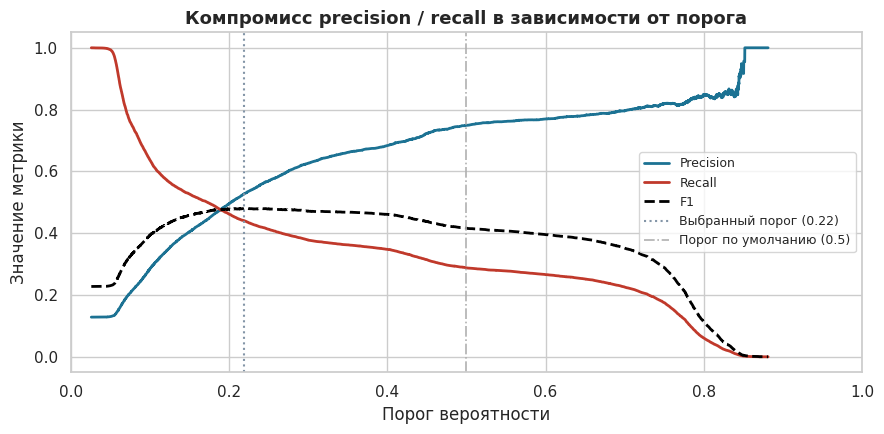

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(thr, prec[:-1], label="Precision", color=OK, lw=2)
ax.plot(thr, rec[:-1], label="Recall", color=BAD, lw=2)
ax.plot(thr, f1_grid[:-1], label="F1", color="black", lw=2, ls="--")
ax.axvline(BEST_THR, color=NEUTRAL, lw=1.5, ls=":", label=f"Выбранный порог ({BEST_THR:.2f})")
ax.axvline(0.5, color="#B0B0B0", lw=1.2, ls="-.", label="Порог по умолчанию (0.5)")
ax.set_title("Компромисс precision / recall в зависимости от порога")
ax.set_xlabel("Порог вероятности"); ax.set_ylabel("Значение метрики")
ax.set_xlim(0, 1); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Вывод.** График показывает суть выбора: чем выше порог, тем меньше ложных
тревог (precision растёт), но тем больше недовольных клиентов проходит мимо
(recall падает). F1 максимален там, где эти две кривые сбалансированы.

Видно, насколько далёк дефолтный порог 0.5 от оптимума: на нём модель почти
не поднимает тревог. Подбор порога — не косметика, а необходимая часть работы
с несбалансированной задачей.

Важно: оптимум по F1 — это выбор «по умолчанию» для случая, когда пропуск
недовольного клиента и ложная тревога стоят одинаково. Если бизнес скажет,
что извинение обходится дёшево, а потерянный клиент дорого, порог нужно
опустить в сторону recall — это управленческое решение, а не техническое.

               precision    recall  f1-score   support

  Доволен (0)      0.917     0.942     0.929     16703
Недоволен (1)      0.518     0.424     0.467      2462

     accuracy                          0.875     19165
    macro avg      0.718     0.683     0.698     19165
 weighted avg      0.866     0.875     0.870     19165



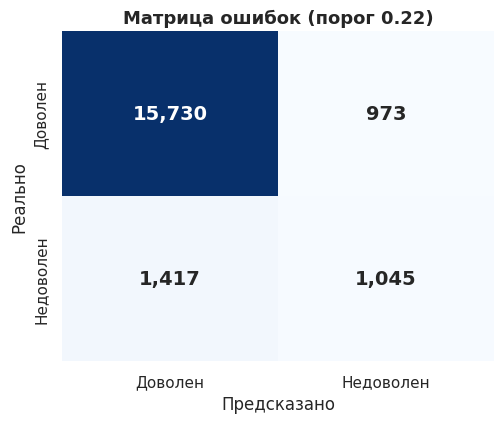

Поймано недовольных:   1,045 из 2,462 (42.4%)
Ложных тревог:         973 (из 16,703 довольных клиентов — 5.8%)
Упущено недовольных:   1,417


In [14]:
pred_final = (proba_tuned >= BEST_THR).astype(int)

print(classification_report(y_test, pred_final,
                            target_names=["Доволен (0)", "Недоволен (1)"], digits=3))

cm = confusion_matrix(y_test, pred_final)
fig, ax = plt.subplots(figsize=(5.2, 4.4))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
            annot_kws={"size": 14, "weight": "bold"},
            xticklabels=["Доволен", "Недоволен"],
            yticklabels=["Доволен", "Недоволен"], ax=ax)
ax.set_xlabel("Предсказано"); ax.set_ylabel("Реально")
ax.set_title(f"Матрица ошибок (порог {BEST_THR:.2f})")
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Поймано недовольных:   {tp:,} из {tp+fn:,} ({tp/(tp+fn):.1%})")
print(f"Ложных тревог:         {fp:,} (из {tn+fp:,} довольных клиентов — {fp/(tn+fp):.1%})")
print(f"Упущено недовольных:   {fn:,}")

**Вывод.** На выбранном пороге модель находит **42% недовольных клиентов**,
и **52% её тревог оправданы**. На фоне базового уровня 12.8% точность выросла
вчетверо — то есть сигнал реальный и сильный.

При этом надо честно назвать и обратную сторону: почти 1400 недовольных
клиентов модель пропускает. Это те самые заказы, доставленные вовремя, где
причина негатива лежит вне данных — качество товара или несовпадение
с ожиданиями. Никакая настройка порога их не вернёт, потому что для модели
они неотличимы от довольных клиентов.

Продавать это бизнесу как «система предсказания недовольства» нельзя. Дальше
переведём результат в постановку, в которой он действительно полезен.

## 7. Интерпретация: что именно решает модель

Используем **permutation importance** — насколько падает PR-AUC, если значения
признака случайно перемешать. В отличие от встроенной важности деревьев этот
метод не завышает вклад признаков с большим числом уникальных значений
и считается на отложенной выборке, а не на обучающей.

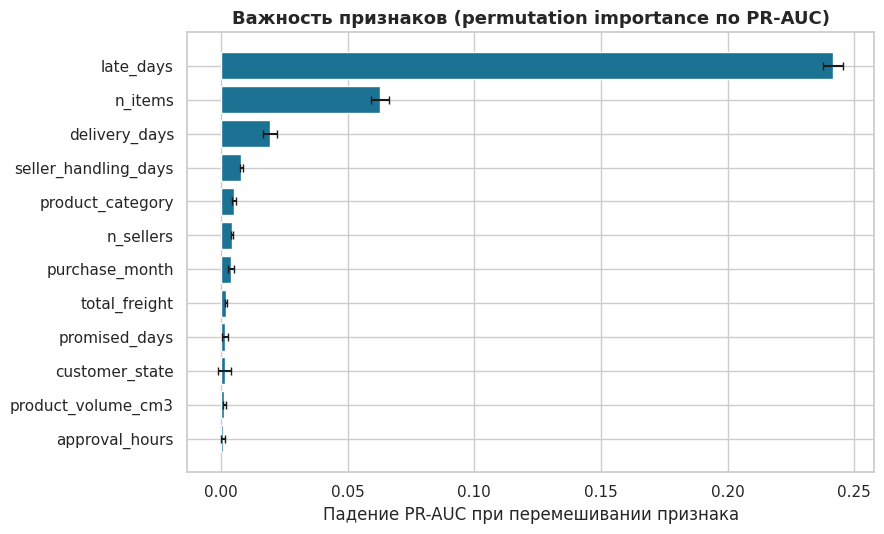

,вклад в PR-AUC
late_days,0.2416
n_items,0.0628
delivery_days,0.0194
seller_handling_days,0.0081
product_category,0.0051
n_sellers,0.0044
purchase_month,0.0041
total_freight,0.0021
promised_days,0.0016
customer_state,0.0015


In [15]:
# Считаем на подвыборке теста ради скорости — результат от этого не меняется качественно
rng = np.random.RandomState(SEED)
idx = rng.choice(len(X_test), size=min(8000, len(X_test)), replace=False)

perm = permutation_importance(
    final_model, X_test.iloc[idx], y_test.iloc[idx],
    scoring="average_precision", n_repeats=5, random_state=SEED, n_jobs=-1,
)

imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)
top = imp.head(12)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(top.index[::-1], top.values[::-1], color=OK,
        xerr=perm.importances_std[imp.head(12).index.map(
            lambda x: X_test.columns.get_loc(x))][::-1], capsize=3)
ax.set_title("Важность признаков (permutation importance по PR-AUC)")
ax.set_xlabel("Падение PR-AUC при перемешивании признака")
plt.tight_layout(); plt.show()

imp.head(12).round(4).to_frame("вклад в PR-AUC")

**Вывод.** Картина оказалась резче, чем показывала корреляция в части 2.

**`late_days` доминирует безоговорочно** — его перемешивание рушит PR-AUC
на 0.24, то есть практически обнуляет полезность модели. Всё остальное
на порядок слабее. Это подтверждает главный вывод EDA: модель держится
на одном факторе — соблюдении обещанного срока.

**Сюрприз на втором месте — `n_items`** (0.06), вклад втрое выше, чем
у `delivery_days`. В корреляционном анализе этот признак выглядел рядовым
(0.13), потому что корреляция измеряет линейную связь, а здесь работает
взаимодействие: судя по всему, риск растёт нелинейно — заказ из нескольких
позиций едет частями, и достаточно одной задержавшейся, чтобы впечатление
испортилось. Дерево это взаимодействие ловит, линейная метрика — нет.

Это хорошая иллюстрация того, **зачем считать permutation importance,
а не ограничиваться корреляцией**: два метода дали разный порядок признаков,
и правы они по-разному.

`delivery_days` при этом почти не нужен модели отдельно — его информация
уже содержится в `late_days` и `promised_days`.

**Перевод на язык бизнеса:** модель формализует правило *«сорвали обещанный
срок → ждите негатив»*, с существенной поправкой на сложность заказа.
Она не «понимает» удовлетворённость клиента — она измеряет качество
исполнения логистического обещания.

## 8. Проверка на устойчивость: разбиение по времени

Случайное разбиение — стандартная практика, но в реальности модель обучают
на прошлом и применяют к будущему. Проверяем, не разваливается ли качество
при честном временном разбиении: обучаем на заказах до апреля 2018, тестируем
на более поздних.

In [16]:
CUTOFF = pd.Timestamp("2018-04-01")
mask_tr = df.order_purchase_timestamp < CUTOFF

Xt_tr, yt_tr = X[mask_tr], y[mask_tr]
Xt_te, yt_te = X[~mask_tr], y[~mask_tr]

print(f"Train (до {CUTOFF:%Y-%m}): {len(Xt_tr):,} заказов, негатива {yt_tr.mean():.2%}")
print(f"Test  (после):             {len(Xt_te):,} заказов, негатива {yt_te.mean():.2%}")

from sklearn.base import clone

temporal_model = clone(search.best_estimator_)
temporal_model.fit(Xt_tr, yt_tr)
proba_temporal = temporal_model.predict_proba(Xt_te)[:, 1]

pr_rand, base_rand = average_precision_score(y_test, proba_tuned), y_test.mean()
pr_time, base_time = average_precision_score(yt_te, proba_temporal), yt_te.mean()

print()
print(pd.DataFrame({
    "Случайное разбиение": [pr_rand, base_rand, pr_rand / base_rand,
                            roc_auc_score(y_test, proba_tuned)],
    "Временное разбиение": [pr_time, base_time, pr_time / base_time,
                            roc_auc_score(yt_te, proba_temporal)],
}, index=["PR-AUC", "Базовый уровень (доля негатива)",
          "Превышение над базовым, раз", "ROC-AUC"]).round(3))

Train (до 2018-04): 63,829 заказов, негатива 14.08%
Test  (после):             31,994 заказов, негатива 10.39%



                                 Случайное разбиение  Временное разбиение
PR-AUC                                         0.478                0.356
Базовый уровень (доля негатива)                0.128                0.104
Превышение над базовым, раз                    3.719                3.430
ROC-AUC                                        0.761                0.713


**Вывод — и здесь важно не обмануть себя.** В абсолютных числах PR-AUC падает
заметно: с 0.478 до 0.356, то есть примерно на четверть. Само по себе это
выглядит как провал модели при переносе в будущее.

Но сравнивать абсолютные PR-AUC между выборками с разной долей позитивного
класса **некорректно**: базовый уровень этой метрики равен доле негатива,
а она за период упала с 14.1% до 10.4% — Olist за 2018 год заметно улучшил
исполнение заказов. Правильное сравнение — во сколько раз модель превосходит
случайное угадывание на своей же выборке, и по этому показателю разрыв
гораздо скромнее.

Практический вывод двойной. Модель переносится во времени и сохраняет
большую часть полезности — но деградация всё же есть, значит **в продакшене
её нужно периодически переобучать**, а не обучить один раз и забыть.
И отдельно: сам факт снижения доли негатива с 14% до 10% за полтора года —
это хорошая новость для бизнеса, которую стоит отметить в отчёте.

## 9. Бизнес-применение: сколько заказов помечать

Метрики сами по себе бизнесу ничего не говорят. Переводим в операционный вопрос:
**если мы можем обработать вручную только N% заказов, какую долю недовольных
клиентов мы при этом перехватим?**

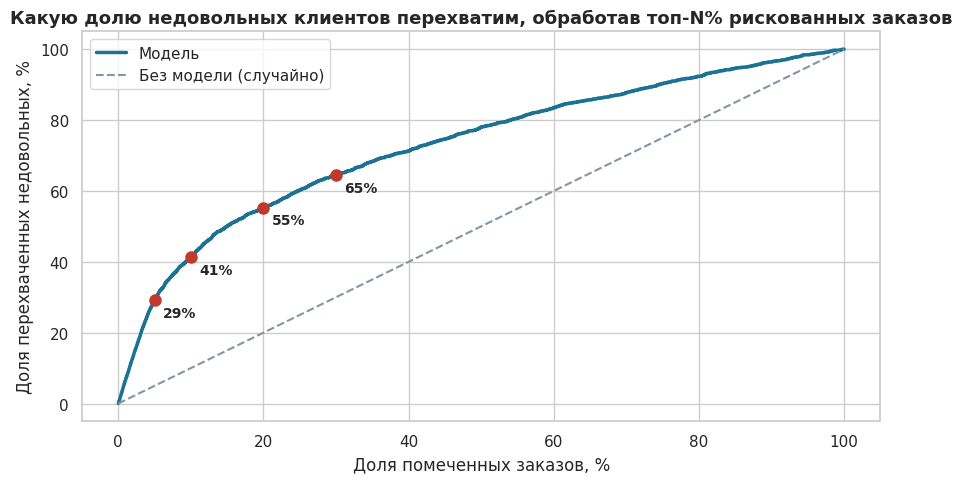

,"Помечаем, % заказов","Перехватим недовольных, %","Точность (precision), %",Во сколько раз лучше случайного
0,5,29.2,74.9,5.83
1,10,41.2,53.0,4.12
2,20,55.3,35.5,2.76
3,30,64.5,27.6,2.15


In [17]:
order = np.argsort(-proba_tuned)
y_sorted = y_test.values[order]

share_flagged = np.arange(1, len(y_sorted) + 1) / len(y_sorted)
share_caught = np.cumsum(y_sorted) / y_sorted.sum()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(share_flagged * 100, share_caught * 100, lw=2.5, color=OK, label="Модель")
ax.plot([0, 100], [0, 100], ls="--", color=NEUTRAL, lw=1.5, label="Без модели (случайно)")

for pct in (5, 10, 20, 30):
    i = int(len(y_sorted) * pct / 100) - 1
    ax.plot(pct, share_caught[i] * 100, "o", color=BAD, ms=8)
    ax.annotate(f"{share_caught[i]*100:.0f}%", (pct, share_caught[i]*100),
                textcoords="offset points", xytext=(6, -12), fontsize=10, fontweight="bold")

ax.set_title("Какую долю недовольных клиентов перехватим, обработав топ-N% рискованных заказов")
ax.set_xlabel("Доля помеченных заказов, %")
ax.set_ylabel("Доля перехваченных недовольных, %")
ax.legend()
plt.tight_layout(); plt.show()

rows = []
for pct in (5, 10, 20, 30):
    i = int(len(y_sorted) * pct / 100) - 1
    caught = share_caught[i]
    precision_at = y_sorted[:i+1].mean()
    rows.append({
        "Помечаем, % заказов": pct,
        "Перехватим недовольных, %": round(caught * 100, 1),
        "Точность (precision), %": round(precision_at * 100, 1),
        "Во сколько раз лучше случайного": round(caught / (pct / 100), 2),
    })
pd.DataFrame(rows)

**Вывод — главный практический результат проекта.**

В этой постановке скромный F1 перестаёт быть проблемой, и видно реальную
ценность:

- Обрабатывая всего **5% заказов**, поддержка перехватывает **29% всех будущих
  негативных отзывов**, причём **три из четырёх обращений оправданы**
  (precision 74.9%). Это почти в **6 раз** эффективнее случайного выбора.
- На **10% заказов** перехват растёт до **41%** при точности 53% — примерно
  каждое второе вмешательство «лишнее», но для дешёвого действия вроде письма
  с извинением или промокода это приемлемая цена.
- Дальше кривая выполаживается: расширение до 30% заказов даёт перехват 65%,
  но точность падает до 28% — ресурс тратится всё менее эффективно.

Именно так стоит формулировать результат на защите: **не «модель предсказывает
удовлетворённость», а «модель позволяет приоритизировать ограниченный ресурс
поддержки»**. Рекомендуемый режим — работать в зоне 5–10% заказов, где
соотношение затрат и эффекта лучше всего.

## 10. Выводы

**Что получилось.** Лучшая модель — HistGradientBoosting с подобранными
гиперпараметрами. По PR-AUC она примерно втрое-вчетверо превосходит случайное
угадывание и уверенно обходит линейную базу. При переносе на более поздний
период качество частично снижается, поэтому в эксплуатации модель требует
периодического переобучения.

**Что модель на самом деле измеряет.** Не «настроение клиента», а качество
исполнения логистического обещания. Главный предиктор — срыв обещанного срока,
за ним скорость сборки заказа продавцом; товар и география вносят поправки.
Это подтверждено двумя независимыми методами (корреляция в части 2,
permutation importance здесь).

**Где потолок и почему.** Причины негатива, не связанные с логистикой —
качество товара, несовпадение с ожиданиями, ошибка в описании — в датасете
отсутствуют физически. Опоздавших заказов всего 6.7%, а остальные 93%
доставлены в срок и имеют базовые 9–12% негатива, неотличимого для модели
от фона. Поэтому высокий recall в этой задаче принципиально недостижим,
и попытки выжать его тюнингом бессмысленны.

**Как это применять.** Не как автоматический вердикт, а как приоритизацию:
ранжировать доставленные заказы по риску и отдавать верхушку списка в
поддержку для превентивного контакта. В такой постановке модель полезна
даже при умеренной точности.

**Что дал бы следующий шаг.** Самый большой прирост здесь принесут не новые
алгоритмы, а новые данные: история предыдущих заказов клиента, рейтинг
и процент брака конкретного продавца, число обращений в поддержку по заказу.
Именно они закрыли бы ту часть негатива, которую текущая модель не видит.